### Basic EDA

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import random

datapath = r"/home/karth-local/rr_dataset/"

In [3]:
events_df = pd.read_csv(datapath + "events.csv")
category_tree_df = pd.read_csv(datapath + "category_tree.csv")
item_properties_part1_df = pd.read_csv(datapath + "item_properties_part1.csv")
item_properties_part2_df = pd.read_csv(datapath + "item_properties_part2.csv")

In [4]:
events_df.columns

Index(['timestamp', 'visitorid', 'event', 'itemid', 'transactionid'], dtype='object')

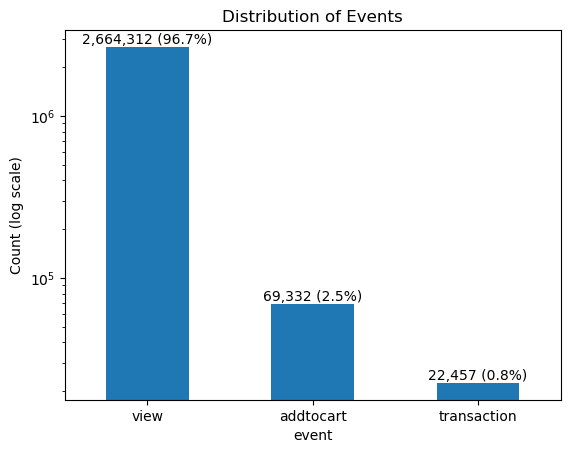

In [5]:
#Descriptive on the event types
counts = events_df.event.value_counts(sort=True, ascending=False)
total = counts.sum()
ax = counts.plot(kind='bar')
ax.set_yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylabel("Count (log scale)",rotation=90)
ax.set_title("Distribution of Events")

for i,v in enumerate(counts):
    pct = v/total * 100
    ax.text(i, v, f"{v:,} ({pct:.1f}%)", ha='center', va='bottom')

In [6]:
# Which events have a transactionid?
events_df[events_df.transactionid.notnull()].event.unique()[0]

'transaction'

In [7]:
#Item properties - which are the most common properties?
item_properties_part1_df.property.value_counts(sort=True,ascending=False).head(5)

property
888           1629817
790            970800
available      817387
categoryid     426305
6              343207
Name: count, dtype: int64

In [8]:
# How many categories are there per parent category (Top 5)?
category_tree_df.groupby("parentid")["categoryid"].nunique().sort_values(ascending=False).reset_index(name="categories").head()

,parentid,categories
0,250.0,31
1,362.0,22
2,1009.0,22
3,351.0,19
4,1259.0,18


In [9]:
item_properties_part1_df.loc[(item_properties_part1_df.property == "categoryid") \
        &(item_properties_part1_df.value == '1016')].sort_values(by='timestamp', \
        ascending=True).head()

,timestamp,itemid,property,value
2105129,1431226800000,377283,categoryid,1016
970935,1431226800000,362999,categoryid,1016
3826363,1431226800000,373242,categoryid,1016
6363096,1431226800000,339403,categoryid,1016
4497603,1431226800000,390209,categoryid,1016


In [10]:
#Customer Funnel Purchases
customers_who_purchased = events_df.loc[events_df.transactionid.notnull()].visitorid.unique()
total_customers = events_df.visitorid.nunique()
print(f"Number of unique customers who made a purchase: {len(customers_who_purchased):,}")
print(f"Number of unique customers: {total_customers:,}")
print(f"Customer purchase rate (%): {len(customers_who_purchased)/total_customers:.2%}")


Number of unique customers who made a purchase: 11,719
Number of unique customers: 1,407,580
Customer purchase rate (%): 0.83%


In [11]:
#Repeat Users
visitors_with_transactions = events_df[events_df.transactionid.notnull()].groupby("visitorid")["transactionid"].nunique()
print(f"Repeat Users: {(visitors_with_transactions > 1).mean():.1%}")

Repeat Users: 9.1%


### Sample Customer Journey

#### Get Data in there for attributes

In [12]:
events_df['readable_timestamp'] = pd.to_datetime(events_df.timestamp,unit = 'ms')

In [13]:
events_df.head()

,timestamp,visitorid,event,itemid,transactionid,readable_timestamp
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106


In [14]:
category_tree_df.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [15]:
item_properties_part1_df.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [16]:
## Choose a sample customer
print(f"Customer of study: {random.choice(customers_who_purchased)}")

Customer of study: 498134


In [ ]:
#### Sample Cell
events_df[events_df.visitorid == 172].sort_values(by='timestamp')

,timestamp,visitorid,event,itemid,transactionid,readable_timestamp
2322316,1436844676639,172,view,397068,NaN,2015-07-14 03:31:16.639
2322362,1436847461448,172,view,55710,NaN,2015-07-14 04:17:41.448
2334717,1436848482402,172,view,464731,NaN,2015-07-14 04:34:42.402
2339403,1436848648303,172,view,403998,NaN,2015-07-14 04:37:28.303
2321448,1436848805277,172,view,18519,NaN,2015-07-14 04:40:05.277
2321557,1436848871619,172,view,27248,NaN,2015-07-14 04:41:11.619
2334804,1436848932823,172,view,363106,NaN,2015-07-14 04:42:12.823
2339539,1436848989537,172,view,10034,NaN,2015-07-14 04:43:09.537
2334643,1436849146584,172,view,302810,NaN,2015-07-14 04:45:46.584
2331918,1436849172774,172,view,10034,NaN,2015-07-14 04:46:12.774


### Funnel Data Building

In [ ]:
#Get Customer Level - First view, addtocart and transaction
events_df_firsts = events_df.groupby(["visitorid","event"])["readable_timestamp"].min().unstack()
events_df_firsts = events_df_firsts[["view","addtocart","transaction"]]

In [19]:
#Issues as the process chain is view --> addtocart --> transaction. If we have timestamp for next but not for previous, then problem
print(f"Data Issues before imputation: {events_df_firsts[(events_df_firsts.addtocart.isna()) & (events_df_firsts.transaction.notna())].size + events_df_firsts[(events_df_firsts.view.isna()) & (events_df_firsts.addtocart.notna())].size:,} records")

#Impute with last stage values
events_df_firsts.addtocart.fillna(events_df_firsts.transaction,inplace = True) #if addtocart missing but transaction not, then fill in
events_df_firsts.view.fillna(events_df_firsts.addtocart,inplace = True) #if view missing but addtocart not, then fill in

print(f"Data Issues after imputation: {events_df_firsts[(events_df_firsts.addtocart.isna()) & (events_df_firsts.transaction.notna())].size + events_df_firsts[(events_df_firsts.view.isna()) & (events_df_firsts.addtocart.notna())].size:,} records")


Data Issues before imputation: 13,392 records
Data Issues after imputation: 0 records


/tmp/ipykernel_1791/1808008210.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  events_df_firsts.addtocart.fillna(events_df_firsts.transaction,inplace = True) #if addtocart missing but transaction not, then fill in
/tmp/ipykernel_1791/1808008210.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

#### Funnel 1 (View to Add to Cart)

In [21]:
#print(f"Avg. time add to cart: {(events_df_firsts.addtocart - events_df_firsts.view).mean()}")
diff_t = events_df_firsts.addtocart - events_df_firsts.view

diff_t.agg(mean="mean",median="median",p25=lambda x: x.quantile(0.25),std="std",min="min",max="max")

mean      2 days 13:58:19.129625807
median       0 days 00:02:24.629000
p25          0 days 00:00:23.373000
std      12 days 00:48:37.501959562
min      -128 days +11:11:21.584000
max        133 days 23:43:23.265000
dtype: timedelta64[ns]

In [43]:
# Cleaning Stage 1: remove Customers with na and negative add to cart timings
diff_t_cleaned = diff_t[diff_t.notna()]
diff_t_cleaned = diff_t[diff_t > pd.Timedelta(0)]
diff_t_cleaned.agg(mean="mean",median="median",p25=lambda x: x.quantile(0.25),std="std",min="min",max="max")

mean      3 days 03:34:57.983114063
median       0 days 00:03:49.427500
p25          0 days 00:00:58.648250
std      12 days 16:01:05.499585211
min          0 days 00:00:00.016000
max        133 days 23:43:23.265000
dtype: timedelta64[ns]

In [46]:
print(len(diff_t_cleaned[diff_t_cleaned <= pd.Timedelta("7D")])/len(diff_t_cleaned))

0.9177925899237375


#### Funnel 1 Summary:

1. Total Customers that had a valid view to addtocart time **33,306**
2. Total Customers that add-to-cart in less than 7 days **30,568**
3. Add to Cart Conversions = **91.79%**

#### Funnel 2 (Add to Cart to Transaction)

In [47]:
diff_t_2 = events_df_firsts.transaction - events_df_firsts.addtocart

diff_t_2.agg(mean="mean",median="median",p25=lambda x: x.quantile(0.25),std="std",min="min",max="max")

mean      0 days 10:59:37.937167505
median       0 days 00:04:56.757000
p25          0 days 00:02:12.157000
std       4 days 10:34:23.331418965
min      -102 days +08:19:22.190000
max        107 days 07:55:49.489000
dtype: timedelta64[ns]

In [53]:
# Cleaning Stage 2: remove Customers with na and negative transaction timings
diff_t_cleaned_2 = diff_t_2[diff_t_2.notna()]
diff_t_cleaned_2 = diff_t_2[diff_t_2 > pd.Timedelta(0)]
diff_t_cleaned_2.agg(mean="mean",median="median",p25=lambda x: x.quantile(0.25),std="std",min="min",max="max")
diff_t_cleaned_2[diff_t_cleaned_2 <= pd.Timedelta("7D")].agg(mean="mean",median="median",p25=lambda x: x.quantile(0.25),std="std",min="min",max="max")

mean     0 days 02:24:28.647002148
median      0 days 00:05:39.457000
p25         0 days 00:02:57.531500
std      0 days 12:57:00.554003298
min         0 days 00:00:22.079000
max         6 days 23:35:29.831000
dtype: timedelta64[ns]

In [ ]:
print(len(diff_t_cleaned_2))
print(len(diff_t_cleaned_2[diff_t_cleaned_2 <= pd.Timedelta("7D")]))
print(len(diff_t_cleaned_2[diff_t_cleaned_2 <= pd.Timedelta("7D")])/len(diff_t_cleaned_2))


10447
10239
0.9800899779841102


#### Funnel 2 Summary:

1. Total Customers that had a valid addtocart to transaction time **10,477**
2. Total Customers that transacted in less than 7 days **10,239**
3. Transaction Conversions = **98.01%**

In [54]:
#Similar overall numbers on overall funnel

diff_t_3 = events_df_firsts.transaction - events_df_firsts.view
diff_t_cleaned_3 = diff_t_3[diff_t_3.notna()]
diff_t_cleaned_3 = diff_t_3[diff_t_3 > pd.Timedelta(0)]
diff_t_cleaned_3[diff_t_cleaned_3 <= pd.Timedelta("7D")].agg(mean="mean",median="median",p25=lambda x: x.quantile(0.25),std="std",min="min",max="max")

mean     0 days 08:09:38.440563723
median      0 days 00:15:03.824000
p25         0 days 00:05:48.170000
std      1 days 00:36:48.603529972
min         0 days 00:00:10.842000
max         6 days 23:58:55.535000
dtype: timedelta64[ns]

In [55]:
print(len(diff_t_cleaned_3))
print(len(diff_t_cleaned_3[diff_t_cleaned_3 <= pd.Timedelta("7D")]))
print(len(diff_t_cleaned_3[diff_t_cleaned_3 <= pd.Timedelta("7D")])/len(diff_t_cleaned_3))

11458
10271
0.89640425903299


#### Full Funnel Summary:

1. Total Customers that had a valid view to transaction time **11,458**
2. Total Customers that transacted in less than 7 days **10,271**
3. Transaction Conversions = **89.65%**

### Other Analysis

#### List of what visitors have brought together and recommend them

In [ ]:
transactions_only = events_df[events_df.transactionid.notnull()]

cust_purchases = []

for cust in transactions_only.visitorid.unique():
    cust_purchases.append(transactions_only[transactions_only.visitorid == cust].itemid.unique().tolist())
    

In [98]:
def recs_simple(item_id,purchase_list):

    rec_list = []

    for l in purchase_list:
        if item_id in l:
            rec_list += l
    
    return {item_id:set([x for x in rec_list if x != item_id])}


In [99]:
print(f"Items purchased similar with item given is: {recs_simple(302422,cust_purchases)}")

Items purchased similar with item given is: {302422: {105792, 200793, 12836, 80582, 380775, 15335, 400969, 25353, 237753, 317178}}
